# Medicare Inpatient Charge-to-Payment Analysis

This project analyzes 2024 CMS Medicare inpatient hospital data to compare average submitted covered charges with average Medicare payments across states, DRGs, and providers. The main metric is the charge-to-Medicare payment ratio, which measures the gap between submitted charges and Medicare reimbursement.

This analysis is descriptive. A high ratio does not prove fraud, overcharging, poor quality, or true cost inefficiency.

## 1. Data Loading

The dataset was loaded from the 2024 CMS Medicare Inpatient Hospitals by Provider and Service file. Identifier fields such as provider CCN, state FIPS, ZIP code, and DRG code were read as strings to preserve leading zeros and avoid treating categorical identifiers as numeric values.

In [2]:
from pathlib import Path 
import pandas as pd 

filepath = Path("../data/raw") / "Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv"

df = pd.read_csv(
    filepath,
    dtype = {
        'Rndrng_Prvdr_CCN': str,
        'Rndrng_Prvdr_State_FIPS': str,
        'Rndrng_Prvdr_Zip5': str,
        'DRG_Cd': str
    })

df.shape

(145879, 15)

## 2. Column Standardization

Column names were converted to lowercase to make the dataframe easier to work with consistently throughout the analysis.

In [3]:
df.columns = df.columns.str.lower()

df.columns

Index(['rndrng_prvdr_ccn', 'rndrng_prvdr_org_name', 'rndrng_prvdr_city',
       'rndrng_prvdr_st', 'rndrng_prvdr_state_fips', 'rndrng_prvdr_zip5',
       'rndrng_prvdr_state_abrvtn', 'rndrng_prvdr_ruca',
       'rndrng_prvdr_ruca_desc', 'drg_cd', 'drg_desc', 'tot_dschrgs',
       'avg_submtd_cvrd_chrg', 'avg_tot_pymt_amt', 'avg_mdcr_pymt_amt'],
      dtype='object')

## 3. Initial Data Audit

The dataset contains 145,879 rows and 15 original columns. There are no missing values and no fully duplicated rows.

This does not mean there are no repeated hospitals. Each row represents a provider-DRG combination, so hospitals correctly appear multiple times across different service lines.

In [4]:
df.head()

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
0,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,023,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,024,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,025,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,038,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [5]:
df.isna().sum()

rndrng_prvdr_ccn             0
rndrng_prvdr_org_name        0
rndrng_prvdr_city            0
rndrng_prvdr_st              0
rndrng_prvdr_state_fips      0
rndrng_prvdr_zip5            0
rndrng_prvdr_state_abrvtn    0
rndrng_prvdr_ruca            0
rndrng_prvdr_ruca_desc       0
drg_cd                       0
drg_desc                     0
tot_dschrgs                  0
avg_submtd_cvrd_chrg         0
avg_tot_pymt_amt             0
avg_mdcr_pymt_amt            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145879 entries, 0 to 145878
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   rndrng_prvdr_ccn           145879 non-null  object 
 1   rndrng_prvdr_org_name      145879 non-null  object 
 2   rndrng_prvdr_city          145879 non-null  object 
 3   rndrng_prvdr_st            145879 non-null  object 
 4   rndrng_prvdr_state_fips    145879 non-null  object 
 5   rndrng_prvdr_zip5          145879 non-null  object 
 6   rndrng_prvdr_state_abrvtn  145879 non-null  object 
 7   rndrng_prvdr_ruca          145879 non-null  float64
 8   rndrng_prvdr_ruca_desc     145879 non-null  object 
 9   drg_cd                     145879 non-null  object 
 10  drg_desc                   145879 non-null  object 
 11  tot_dschrgs                145879 non-null  int64  
 12  avg_submtd_cvrd_chrg       145879 non-null  float64
 13  avg_tot_pymt_amt           14

## 4. Numeric Field Review

The numeric summary shows wide variation in discharge volume, submitted charges, total payments, and Medicare payments. This supports the need to review extreme values and avoid relying only on simple averages.

In [8]:
df[['tot_dschrgs',
    'avg_submtd_cvrd_chrg', 
    'avg_tot_pymt_amt', 
    'avg_mdcr_pymt_amt']].describe()

,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt
count,145879.000000,1.458790e+05,1.458790e+05,1.458790e+05
mean,33.949239,9.636609e+04,1.915132e+04,1.578265e+04
std,50.571682,1.293347e+05,2.267339e+04,1.966287e+04
min,11.000000,2.058385e+03,1.849077e+03,3.868000e+02
25%,14.000000,3.684523e+04,9.057232e+03,7.078129e+03
50%,20.000000,6.161959e+04,1.321742e+04,1.085070e+04
75%,35.000000,1.100423e+05,2.095995e+04,1.725262e+04
max,3400.000000,7.196637e+06,1.443310e+06,1.436668e+06


## 5. Core KPI Creation

The main project metric is the charge-to-Medicare payment ratio:

`avg_submtd_cvrd_chrg / avg_mdcr_pymt_amt`

A ratio of 8 means the average submitted covered charge was about eight times the average Medicare payment for that provider-DRG row. This measures the charge-to-payment gap, not actual hospital cost or profit.

In [9]:
df['charge_to_medicare_payment_ratio'] = df['avg_submtd_cvrd_chrg'] / df['avg_mdcr_pymt_amt']

df.head()

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
0,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818,8.095739
1,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,023,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217,4.611773
2,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,024,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692,3.728442
3,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,025,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636,7.856666
4,010001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,01,36301,AL,2.0,Metropolitan area high commuting: primary flow...,038,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222,10.569332


## 6. Highest and Lowest Row-Level Ratios

The highest row-level ratios show provider-DRG combinations where submitted charges are much larger than Medicare payments. The lowest ratios show cases where Medicare payments are greater than submitted charges.

These rows are useful for investigation, but they should not automatically be treated as errors or evidence of misconduct.

In [10]:
df.sort_values('charge_to_medicare_payment_ratio', ascending = False).head(10)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
133953,470001,Central Vermont Medical Center,Berlin,130 Fisher Road,50,05641,VT,4.0,Micropolitan area core: primary flow within an...,310,CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WI...,15,20474.866667,2102.866667,386.800000,52.933988
86691,310092,Capital Health Regional Medical Center,Trenton,750 Brunswick Ave,34,08638,NJ,1.0,Metropolitan area core: primary flow within an...,493,LOWER EXTREMITY AND HUMERUS PROCEDURES EXCEPT ...,11,705735.727270,60665.272727,14156.545455,49.852256
2028,010131,Crestwood Medical Center,Huntsville,One Hospital Dr Se,01,35801,AL,1.0,Metropolitan area core: primary flow within an...,282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE ...",19,112002.684210,5515.052632,2265.736842,49.433227
84856,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,310,CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WI...,17,190458.823530,7310.294118,3897.235294,48.870240
84884,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,812,RED BLOOD CELL DISORDERS WITHOUT MCC,16,322010.375000,9792.375000,7184.937500,44.817422
84844,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,178,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH CC,27,287831.333330,10039.259259,6875.703704,41.862091
138075,490118,Henrico Doctors' Hospital,Richmond,1602 Skipwith Road,51,23229,VA,1.0,Metropolitan area core: primary flow within an...,652,KIDNEY TRANSPLANT,15,742314.866670,35878.200000,17900.000000,41.470104
86675,310092,Capital Health Regional Medical Center,Trenton,750 Brunswick Ave,34,08638,NJ,1.0,Metropolitan area core: primary flow within an...,189,PULMONARY EDEMA AND RESPIRATORY FAILURE,19,561007.894740,16467.842105,13613.526316,41.209594
84841,310044,Capital Health Medical Center - Hopewell,Pennington,One Capital Way,34,08534,NJ,1.0,Metropolitan area core: primary flow within an...,065,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,12,335489.666670,10211.916667,8420.916667,39.840041
35223,100264,Hca Florida Oak Hill Hospital,Brooksville,11375 Cortez Blvd,12,34613,FL,1.1,Secondary flow 30% to <50% to a larger urbaniz...,418,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WI...,19,412962.578950,15116.736842,10422.842105,39.620919


In [11]:
df.sort_values('charge_to_medicare_payment_ratio', ascending = False).tail(10)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,rndrng_prvdr_state_abrvtn,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
128569,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,065,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,11,35582.181818,115205.09091,111835.81818,0.318164
48251,140300,Provident Hospital Of Chicago,Chicago,500 E 51st St,17,60615,IL,1.0,Metropolitan area core: primary flow within an...,291,HEART FAILURE AND SHOCK WITH MCC,16,26236.937500,86722.37500,84063.06250,0.312110
128574,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,640,"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLI...",14,35789.642857,129344.71429,125347.07143,0.285524
128571,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,190,CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC,18,30617.000000,120408.44444,117772.72222,0.259967
128572,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,291,HEART FAILURE AND SHOCK WITH MCC,46,29614.956522,124840.02174,121091.71739,0.244566
128575,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,690,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,15,28639.800000,127043.13333,121685.86667,0.235358
128580,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,872,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,16,25442.625000,126576.18750,122325.12500,0.207992
128576,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,699,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,12,23168.833333,127767.66667,124017.58333,0.186819
128577,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,812,RED BLOOD CELL DISORDERS WITHOUT MCC,11,19817.181818,123196.45455,119455.72727,0.165896
128573,450289,Harris Health,Houston,1504 Taub Loop,48,77030,TX,1.0,Metropolitan area core: primary flow within an...,638,DIABETES WITH CC,14,19472.928571,127285.35714,123937.35714,0.157119


## 7. Unusual Payment Relationship Check

Some rows show average Medicare payments or average total payments exceeding average submitted charges. These records were flagged for review rather than removed.

Because the data comes from CMS and payment fields can include complex reimbursement components, unusual relationships are not enough by themselves to justify deletion.

In [12]:
payment_exceeds_charges = df['avg_mdcr_pymt_amt'] > df['avg_submtd_cvrd_chrg']

df[payment_exceeds_charges].shape[0]

121

In [13]:
total_payments_exceeds_charges = df['avg_tot_pymt_amt'] > df['avg_submtd_cvrd_chrg']

df[total_payments_exceeds_charges].shape[0]

223

In [14]:
condition = payment_exceeds_charges | total_payments_exceeds_charges 

investigation_cols = [
    'drg_desc',
    'rndrng_prvdr_org_name',
    'rndrng_prvdr_state_abrvtn',
    'tot_dschrgs',
    'avg_submtd_cvrd_chrg',
    'avg_tot_pymt_amt',
    'avg_mdcr_pymt_amt',
    'charge_to_medicare_payment_ratio'
]

investigation_table = df.loc[condition, investigation_cols].sort_values(
    'charge_to_medicare_payment_ratio'
)

investigation_table.head(20)


,drg_desc,rndrng_prvdr_org_name,rndrng_prvdr_state_abrvtn,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,charge_to_medicare_payment_ratio
128573,DIABETES WITH CC,Harris Health,TX,14,19472.928571,127285.357140,123937.357140,0.157119
128577,RED BLOOD CELL DISORDERS WITHOUT MCC,Harris Health,TX,11,19817.181818,123196.454550,119455.727270,0.165896
128576,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,Harris Health,TX,12,23168.833333,127767.666670,124017.583330,0.186819
128580,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,Harris Health,TX,16,25442.625000,126576.187500,122325.125000,0.207992
128575,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,Harris Health,TX,15,28639.800000,127043.133330,121685.866670,0.235358
128572,HEART FAILURE AND SHOCK WITH MCC,Harris Health,TX,46,29614.956522,124840.021740,121091.717390,0.244566
128571,CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC,Harris Health,TX,18,30617.000000,120408.444440,117772.722220,0.259967
128574,"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLI...",Harris Health,TX,14,35789.642857,129344.714290,125347.071430,0.285524
48251,HEART FAILURE AND SHOCK WITH MCC,Provident Hospital Of Chicago,IL,16,26236.937500,86722.375000,84063.062500,0.312110
128569,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,Harris Health,TX,11,35582.181818,115205.090910,111835.818180,0.318164


## 8. Initial State-Level Analysis: Unweighted Ratio

This table ranks states by the simple average of row-level charge-to-Medicare payment ratios. Nevada, Colorado, Florida, New Jersey, and Texas appear among the highest states using this unweighted method.

This is an initial view only. Because each provider-DRG row receives equal weight, low-volume rows may have too much influence on the ranking.

In [15]:
ratio_by_state = df.groupby('rndrng_prvdr_state_abrvtn').agg({ 'charge_to_medicare_payment_ratio': 'mean', 'tot_dschrgs': 'sum'}).sort_values(by = 'charge_to_medicare_payment_ratio', ascending = False)

ratio_by_state

,charge_to_medicare_payment_ratio,tot_dschrgs
rndrng_prvdr_state_abrvtn,,
NV,11.401296,43206
CO,9.337752,44567
FL,9.274928,444244
NJ,8.881764,176887
TX,8.492929,334970
CA,7.765950,462315
KS,7.502259,52642
AL,7.500724,67132
AZ,7.359614,96271


## 9. DRG-Level Analysis

DRGs were grouped to identify service lines with the highest average charge-to-Medicare payment ratios. The initial unfiltered DRG ranking included several low-volume DRGs, showing why volume context matters.

In [16]:
drg_summary = df.groupby(['drg_cd', 'drg_desc']).agg({'charge_to_medicare_payment_ratio': 'mean', 'tot_dschrgs': 'sum'}).sort_values(by = 'charge_to_medicare_payment_ratio', ascending = False)

drg_summary.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
581,"OTHER SKIN, SUBCUTANEOUS TISSUE AND BREAST PROCEDURES WITHOUT CC/MCC",24.038569,91
714,TRANSURETHRAL PROSTATECTOMY WITHOUT CC/MCC,22.538549,15
585,"BREAST BIOPSY, LOCAL EXCISION AND OTHER BREAST PROCEDURES WITHOUT CC/MCC",18.065739,35
350,INGUINAL AND FEMORAL HERNIA PROCEDURES WITH MCC,14.800563,11
652,KIDNEY TRANSPLANT,13.991271,6202
089,CONCUSSION WITH CC,13.363651,94
513,"HAND OR WRIST PROCEDURES, EXCEPT MAJOR THUMB OR JOINT PROCEDURES WITH CC/MCC",12.829160,33
030,SPINAL PROCEDURES WITHOUT CC/MCC,12.656546,20
504,FOOT PROCEDURES WITH CC,12.524108,13


## 10. Meaningful-Volume DRG Filter

A minimum threshold of 100 total discharges was applied to reduce the influence of extremely low-volume DRGs. After filtering, kidney transplant DRGs remained highly ranked, suggesting that these service lines show large charge-to-Medicare payment gaps even with meaningful discharge volume.

In [17]:
meaningful_volume_drg = drg_summary[drg_summary['tot_dschrgs'] >= 100]

meaningful_volume_drg.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
652,KIDNEY TRANSPLANT,13.991271,6202
651,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITHOUT MCC,11.042153,487
087,TRAUMATIC STUPOR AND COMA <1 HOUR WITHOUT CC/MCC,10.334008,1091
650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,10.132530,2130
440,DISORDERS OF PANCREAS EXCEPT MALIGNANCY WITHOUT CC/MCC,9.880385,263
068,PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,9.571110,549
282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE WITHOUT CC/MCC",9.561404,5809
419,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WITHOUT CC/MCC,9.465131,2460
066,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION WITHOUT CC/MCC,9.329680,9902


## 11. Initial State and DRG Visualizations

The initial bar charts summarize the highest and lowest state-level ratios and the highest-ratio meaningful-volume DRGs.

These visuals are useful for exploration, but the final dashboard should clarify whether the ratios are unweighted or discharge-weighted.

C:\Users\gurba\AppData\Local\Temp\ipykernel_4032\3889417015.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


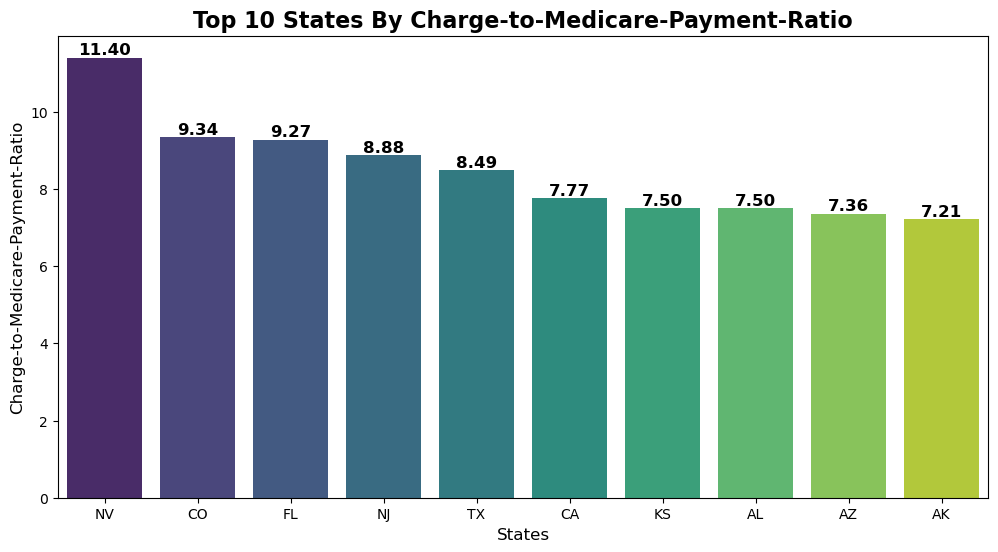

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 6))

ax = sns.barplot(
    data = ratio_by_state.head(10),
    x = 'rndrng_prvdr_state_abrvtn',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, fontweight='bold')

plt.title('Top 10 States By Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')
plt.xlabel('States', fontsize = 12)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 12)

plt.show()


C:\Users\gurba\AppData\Local\Temp\ipykernel_4032\156239289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


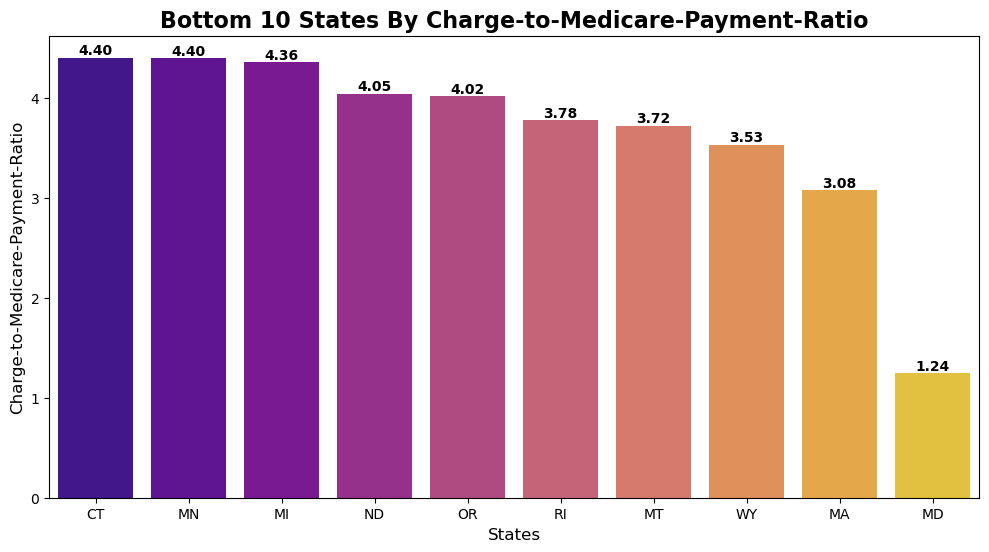

In [19]:
plt.figure(figsize = (12, 6))

ax = sns.barplot(
    data = ratio_by_state.tail(10),
    x = 'rndrng_prvdr_state_abrvtn',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'plasma')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, fontweight='bold')

plt.title('Bottom 10 States By Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')
plt.xlabel('States', fontsize = 12)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 12)

plt.show()


In [20]:
meaningful_volume_drg.head(10)

,,charge_to_medicare_payment_ratio,tot_dschrgs
drg_cd,drg_desc,,
652,KIDNEY TRANSPLANT,13.991271,6202
651,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITHOUT MCC,11.042153,487
087,TRAUMATIC STUPOR AND COMA <1 HOUR WITHOUT CC/MCC,10.334008,1091
650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,10.132530,2130
440,DISORDERS OF PANCREAS EXCEPT MALIGNANCY WITHOUT CC/MCC,9.880385,263
068,PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,9.571110,549
282,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE WITHOUT CC/MCC",9.561404,5809
419,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WITHOUT CC/MCC,9.465131,2460
066,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION WITHOUT CC/MCC,9.329680,9902


C:\Users\gurba\AppData\Local\Temp\ipykernel_4032\4113561749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


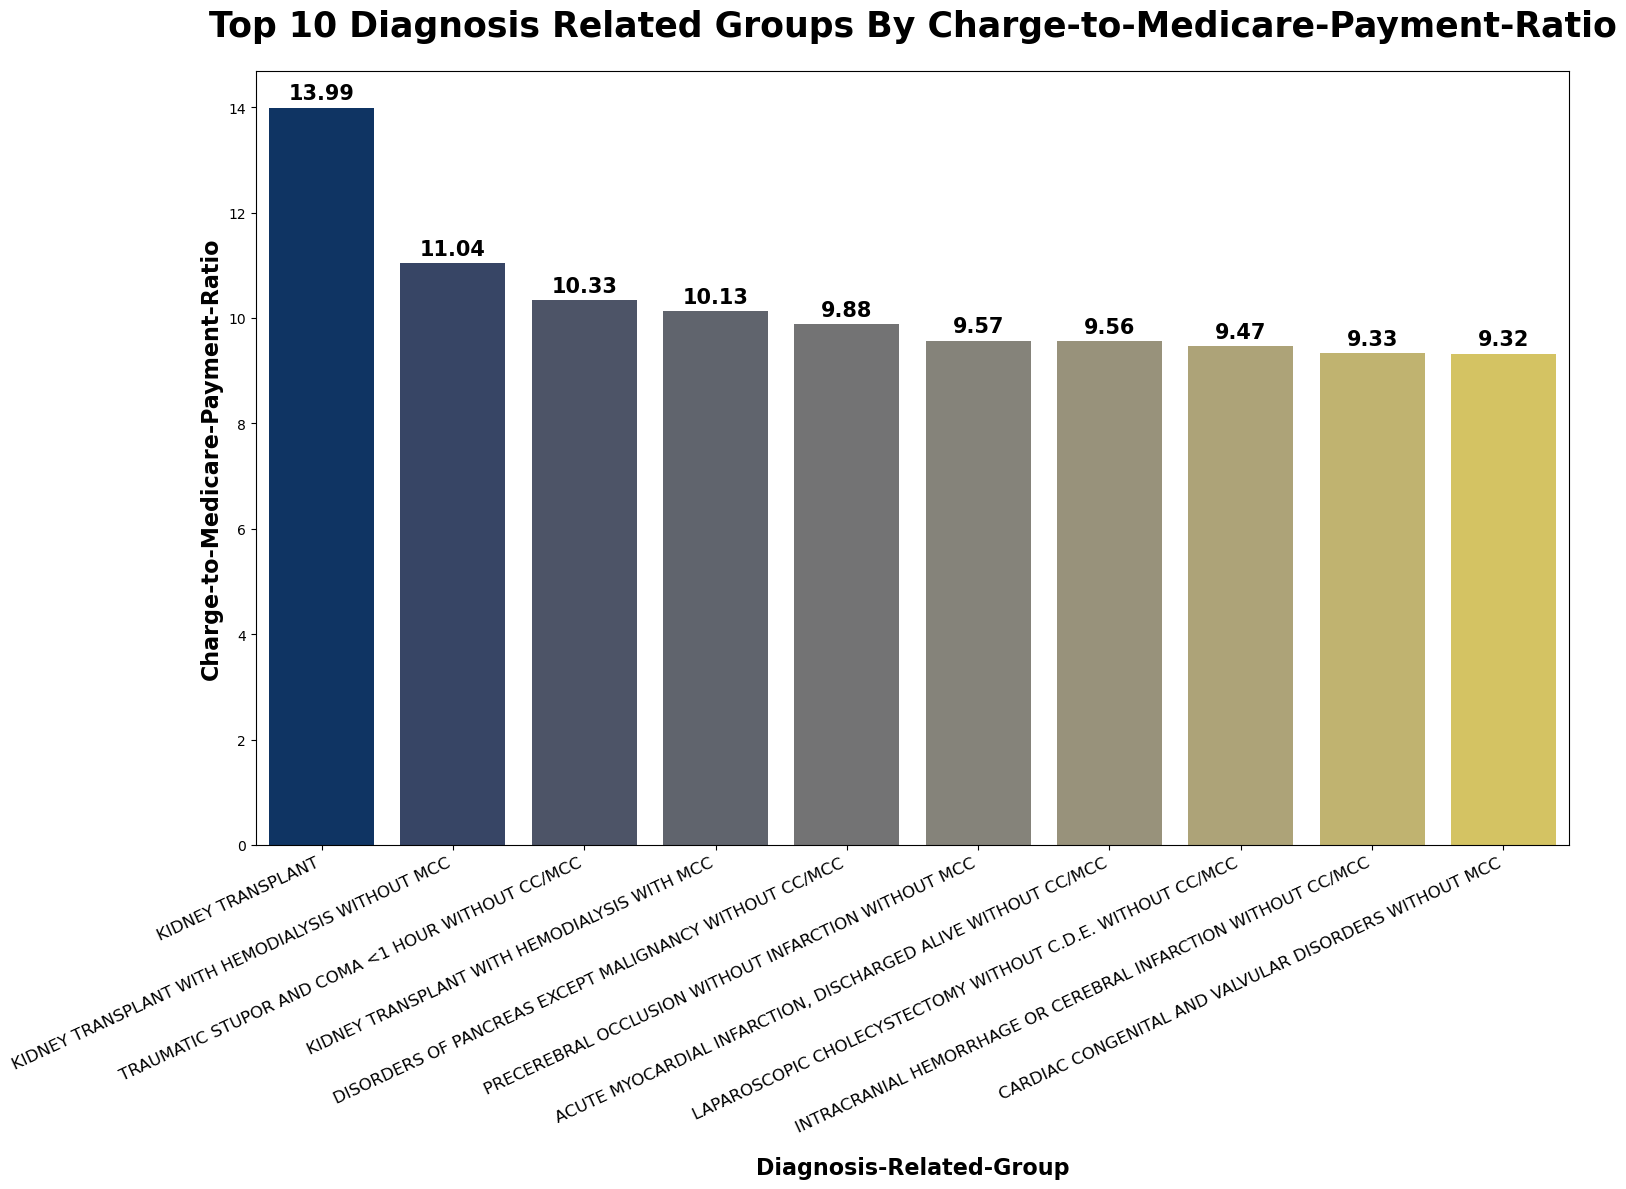

In [21]:
plt.figure(figsize = (16, 12))

ax = sns.barplot(
    data = meaningful_volume_drg.head(10),
    x = 'drg_desc',
    y = 'charge_to_medicare_payment_ratio',
    palette = 'cividis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=15, fontweight='bold')

plt.title('Top 10 Diagnosis Related Groups By Charge-to-Medicare-Payment-Ratio', fontsize = 25, fontweight = 'bold', pad = 25)
plt.xlabel('Diagnosis-Related-Group', fontsize = 16, fontweight = 'bold', labelpad = 15)
plt.ylabel('Charge-to-Medicare-Payment-Ratio', fontsize = 16, fontweight = 'bold')

plt.xticks(rotation = 25, ha = 'right', fontsize = 12)
plt.tight_layout()

plt.show()


## 12. Provisional Hospital-Level Analysis

Hospitals were initially grouped by organization name to identify high- and low-ratio providers with at least 100 total discharges.

This ranking is provisional because organization names are not guaranteed to be unique provider identifiers. The provider CCN should be used for final provider-level analysis.

In [22]:
hospital_summary = (
    df.groupby('rndrng_prvdr_org_name')
        .agg({
            'charge_to_medicare_payment_ratio': 'mean', 
            'tot_dschrgs': 'sum'
        })
        .sort_values(
            by = 'charge_to_medicare_payment_ratio', 
            ascending = False
        )
)

hospital_summary

,charge_to_medicare_payment_ratio,tot_dschrgs
rndrng_prvdr_org_name,,
Capital Health Medical Center - Hopewell,30.253010,1447
Capital Health Regional Medical Center,28.482212,1109
Exceptional Community Hospital Yuma,27.820847,29
Carepoint Health - Bayonne Medical Center,23.682464,502
Gadsden Regional Medical Center,21.438660,1047
...,...,...
Washington County Regional Medical Center,0.854610,11
John H Stroger Jr Hospital,0.781071,318
Tuba City Regional Health Care Corporation,0.759660,174


In [23]:
hospital_summary['tot_dschrgs'].describe()

count     2845.000000
mean      1740.766608
std       2349.418697
min         11.000000
25%        252.000000
50%        872.000000
75%       2343.000000
max      30767.000000
Name: tot_dschrgs, dtype: float64

In [24]:
meaningful_volume_hospitals = hospital_summary[hospital_summary['tot_dschrgs'] >= 100]

meaningful_volume_hospitals.shape[0]

2498

In [25]:
meaningful_volume_hospitals.head(10)

,charge_to_medicare_payment_ratio,tot_dschrgs
rndrng_prvdr_org_name,,
Capital Health Medical Center - Hopewell,30.253010,1447
Capital Health Regional Medical Center,28.482212,1109
Carepoint Health - Bayonne Medical Center,23.682464,502
Gadsden Regional Medical Center,21.438660,1047
Centennial Hills Hospital Medical Center,20.426339,2334
Hca Florida Twin Cities Hospital,20.345488,428
Crestwood Medical Center,20.100923,1440
Hca Florida South Shore Hospital,19.617813,1474
Doctors Medical Center,19.403442,2691


In [26]:
meaningful_volume_hospitals.tail(10)

,charge_to_medicare_payment_ratio,tot_dschrgs
rndrng_prvdr_org_name,,
Cambridge Health Alliance,1.182560,605
Umd Shore Medical Ctr At Chestertown,1.169722,155
University Of Maryland Medical Center,1.144781,4732
University Of Md Capital Region Medical Center,1.134718,1555
Wilmington Treatment Center,1.067174,426
University Health Truman Medical Center,1.036753,219
University Of Md Charles Regional Medical Center,0.992964,1678
John H Stroger Jr Hospital,0.781071,318
Tuba City Regional Health Care Corporation,0.759660,174


In [27]:
hospital_state_count = (
    df.groupby('rndrng_prvdr_state_abrvtn').agg
    ({
        'charge_to_medicare_payment_ratio': 'mean',
        'tot_dschrgs': 'sum',
        'rndrng_prvdr_org_name': 'nunique'
    })
    .sort_values(by = 'charge_to_medicare_payment_ratio',
                 ascending = False)
    )

hospital_state_count

,charge_to_medicare_payment_ratio,tot_dschrgs,rndrng_prvdr_org_name
rndrng_prvdr_state_abrvtn,,,
NV,11.401296,43206,21
CO,9.337752,44567,47
FL,9.274928,444244,165
NJ,8.881764,176887,61
TX,8.492929,334970,241
CA,7.765950,462315,271
KS,7.502259,52642,43
AL,7.500724,67132,69
AZ,7.359614,96271,60


In [28]:
top_drg = meaningful_volume_drg.index[0]

top_drg

('652', 'KIDNEY TRANSPLANT')

## 13. Preliminary KPI Summary

The preliminary KPI table summarizes the national average ratio, highest- and lowest-ratio states, highest- and lowest-ratio hospitals, and highest-ratio meaningful-volume DRG.

This table is a starting point, but the final version should use validated weighted metrics and CCN-based provider grouping.

In [29]:
kpi_data = {
    "National Average Ratio": round(df['charge_to_medicare_payment_ratio'].mean(), 3),
    'Highest Ratio State': ratio_by_state.index[0],
    'Lowest Ratio State': ratio_by_state.index[-1],
    'Highest Ratio Hospital': meaningful_volume_hospitals.index[0],
    'Lowest Ratio Hospital': meaningful_volume_hospitals.index[-1],
    'Highest Ratio DRG': top_drg[1]
}

kpi_table = pd.DataFrame([kpi_data])

kpi_table

,National Average Ratio,Highest Ratio State,Lowest Ratio State,Highest Ratio Hospital,Lowest Ratio Hospital,Highest Ratio DRG
0,6.476,NV,MD,Capital Health Medical Center - Hopewell,Harris Health,KIDNEY TRANSPLANT


In [30]:
mean_ratio_unweighted_state = df.groupby('rndrng_prvdr_state_abrvtn').agg({'charge_to_medicare_payment_ratio': 'mean'}).sort_values(by = 'charge_to_medicare_payment_ratio', ascending = False)

mean_ratio_unweighted_state

,charge_to_medicare_payment_ratio
rndrng_prvdr_state_abrvtn,
NV,11.401296
CO,9.337752
FL,9.274928
NJ,8.881764
TX,8.492929
CA,7.765950
KS,7.502259
AL,7.500724
AZ,7.359614


In [31]:
weights = df[['rndrng_prvdr_state_abrvtn', 'avg_submtd_cvrd_chrg', 'avg_mdcr_pymt_amt', 'tot_dschrgs']].copy()

weights['total_charges_raw'] = weights['avg_submtd_cvrd_chrg'] * weights['tot_dschrgs']
weights['total_medicare_raw'] = weights['avg_mdcr_pymt_amt'] * weights['tot_dschrgs']

state_totals = weights.groupby('rndrng_prvdr_state_abrvtn').agg({
    'total_charges_raw': 'sum',
    'total_medicare_raw': 'sum'
})

charge_to_medicare_ratio_weighted_state = (
    state_totals['total_charges_raw'] / state_totals['total_medicare_raw']
).sort_values(ascending=False)

charge_to_medicare_ratio_weighted_state



rndrng_prvdr_state_abrvtn
NV    10.750248
CO     8.724345
FL     8.514710
TX     8.174734
NJ     7.940118
CA     7.325531
KS     7.140657
PA     7.097391
AL     7.027603
AK     6.612173
AZ     6.566828
SC     6.496402
TN     6.280101
GA     6.225714
OK     6.187712
NY     6.125765
LA     6.078183
KY     6.006407
VA     5.799831
VT     5.761952
DC     5.588606
WA     5.477417
IN     5.468484
MO     5.449270
IL     5.429472
WV     5.409645
OH     5.379253
MS     5.353948
ID     5.147567
SD     5.057678
NM     5.023386
WI     4.828107
NH     4.757475
IA     4.739443
AR     4.707221
NC     4.688604
NE     4.607256
ME     4.563845
HI     4.409418
UT     4.407928
MI     4.179685
DE     4.177479
CT     4.138006
MN     4.092176
ND     3.806576
OR     3.765985
RI     3.420703
MT     3.333881
WY     3.331053
MA     3.148694
MD     1.209840
dtype: float64

## 15. State Methodology Comparison

After weighting by discharge volume, the highest-ranking states remain broadly similar. Nevada, Colorado, and Florida stay in the top three, while Texas moves ahead of New Jersey.

This suggests the state-level pattern is fairly stable, but the discharge-weighted ratio is more appropriate for final business interpretation.

In [32]:
state_methodology_comparison = pd.concat(
    [
        mean_ratio_unweighted_state,
        charge_to_medicare_ratio_weighted_state
    ], axis = 1
)

state_methodology_comparison.columns = ['unweighted_ratio', 'weighted_ratio']

state_methodology_comparison['difference'] = state_methodology_comparison['unweighted_ratio'] - state_methodology_comparison['weighted_ratio']

state_methodology_comparison['Total Discharges'] = weights.groupby('rndrng_prvdr_state_abrvtn')['tot_dschrgs'].sum()

state_methodology_comparison['Unique Providers'] = df.groupby('rndrng_prvdr_state_abrvtn')['rndrng_prvdr_ccn'].nunique()

state_methodology_comparison['unweighted_rank'] = (
    state_methodology_comparison['unweighted_ratio'].rank(ascending = False)
)

state_methodology_comparison['weighted_rank'] = (
    state_methodology_comparison['weighted_ratio'].rank(ascending = False)
)

state_methodology_comparison['rank_change'] = state_methodology_comparison['unweighted_rank'] - state_methodology_comparison['weighted_rank']

state_methodology_comparison

,unweighted_ratio,weighted_ratio,difference,Total Discharges,Unique Providers,unweighted_rank,weighted_rank,rank_change
rndrng_prvdr_state_abrvtn,,,,,,,,
NV,11.401296,10.750248,0.651048,43206,21,1.0,1.0,0.0
CO,9.337752,8.724345,0.613406,44567,47,2.0,2.0,0.0
FL,9.274928,8.514710,0.760218,444244,165,3.0,3.0,0.0
NJ,8.881764,7.940118,0.941646,176887,61,4.0,5.0,-1.0
TX,8.492929,8.174734,0.318195,334970,241,5.0,4.0,1.0
CA,7.765950,7.325531,0.440419,462315,272,6.0,6.0,0.0
KS,7.502259,7.140657,0.361603,52642,43,7.0,7.0,0.0
AL,7.500724,7.027603,0.473121,67132,69,8.0,9.0,-1.0
AZ,7.359614,6.566828,0.792787,96271,60,9.0,11.0,-2.0


The discharge-weighted ratios are consistently lower than the unweighted ratios, which suggests that low volume artificially inflates the simple mean. Despite this, the highest ranking states remained widely similar after calculating the weighted ratios, so the state-level pattern is still stable. For final reporting, the weighted ratio is stronger because it accounts for discharge volume.

In [33]:
df['estimated_total_charges'] = df['avg_submtd_cvrd_chrg'] * df['tot_dschrgs']
df['estimated_total_medicare_payments'] = df['avg_mdcr_pymt_amt'] * df['tot_dschrgs']

## 16. DRG Methodology Comparison

After weighting by discharge volume, many DRG's within the top 10 had significant movements. THYROID, PARATHYROID AND THYROGLOSSAL PROCEDURES WITHOUT CC/MCC moved up 67 rank positions, TRANSIENT ISCHEMIA WITHOUT THROMBOLYTIC moved up 8 positions, KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC	fell six positions. 

This suggests that simple, drg-level averages are much more sensitive to low volumes, and hence, the drg-weighted ratio is more appropriate for final business interpretation.

In [34]:
drg_methodology_comparison = df.groupby(['drg_cd', 'drg_desc']).agg(
    unweighted_ratio = ('charge_to_medicare_payment_ratio', 'mean'),
    estimated_total_charges = ('estimated_total_charges', 'sum'),
    estimated_total_medicare_payments = ('estimated_total_medicare_payments', 'sum'), 
    total_discharges = ('tot_dschrgs', 'sum')
)

drg_methodology_comparison['weighted_ratio'] = (
    drg_methodology_comparison['estimated_total_charges'] /
    drg_methodology_comparison['estimated_total_medicare_payments']
)

drg_methodology_comparison['difference'] = (
    drg_methodology_comparison['unweighted_ratio'] -
    drg_methodology_comparison['weighted_ratio']
)

meaningful_volume_drg_weighted = (
    drg_methodology_comparison[drg_methodology_comparison['total_discharges'] >= 100]
    .sort_values(by = 'weighted_ratio', ascending = False)
)

meaningful_volume_drg_weighted['unweighted_rank'] = (
    meaningful_volume_drg_weighted['unweighted_ratio'].rank(ascending = False)
)

meaningful_volume_drg_weighted['weighted_rank'] = (
    meaningful_volume_drg_weighted['weighted_ratio'].rank(ascending = False)
)

meaningful_volume_drg_weighted['rank_change'] = (
    meaningful_volume_drg_weighted['unweighted_rank'] -
    meaningful_volume_drg_weighted['weighted_rank']
)

meaningful_volume_drg_weighted[['unweighted_ratio','weighted_ratio', 'difference', 'total_discharges', 'unweighted_rank', 'weighted_rank', 'rank_change' ]].head(10)

,,unweighted_ratio,weighted_ratio,difference,total_discharges,unweighted_rank,weighted_rank,rank_change
drg_cd,drg_desc,,,,,,,
652,KIDNEY TRANSPLANT,13.991271,12.666740,1.324531,6202,1.0,1.0,0.0
627,"THYROID, PARATHYROID AND THYROGLOSSAL PROCEDURES WITHOUT CC/MCC",7.465950,10.372941,-2.906991,216,69.0,2.0,67.0
087,TRAUMATIC STUPOR AND COMA <1 HOUR WITHOUT CC/MCC,10.334008,10.236952,0.097055,1091,3.0,3.0,0.0
651,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITHOUT MCC,11.042153,9.775835,1.266318,487,2.0,4.0,-2.0
440,DISORDERS OF PANCREAS EXCEPT MALIGNANCY WITHOUT CC/MCC,9.880385,9.659034,0.221351,263,5.0,5.0,0.0
068,PRECEREBRAL OCCLUSION WITHOUT INFARCTION WITHOUT MCC,9.571110,9.430290,0.140820,549,6.0,6.0,0.0
446,DISORDERS OF THE BILIARY TRACT WITHOUT CC/MCC,9.310463,9.415487,-0.105024,495,11.0,7.0,4.0
069,TRANSIENT ISCHEMIA WITHOUT THROMBOLYTIC,9.113606,9.373655,-0.260049,20244,16.0,8.0,8.0
103,HEADACHES WITHOUT MCC,9.256089,9.335068,-0.078979,2179,13.0,9.0,4.0


In [35]:
largest_drg_rank_change = meaningful_volume_drg_weighted[['unweighted_ratio','weighted_ratio', 'difference', 'total_discharges', 'unweighted_rank', 'weighted_rank', 'rank_change' ]].sort_values(by = 'rank_change', ascending = False)

largest_drg_rank_change.head(10)

,,unweighted_ratio,weighted_ratio,difference,total_discharges,unweighted_rank,weighted_rank,rank_change
drg_cd,drg_desc,,,,,,,
205,OTHER RESPIRATORY SYSTEM DIAGNOSES WITH MCC,5.868305,6.501145,-0.632840,4459,323.0,181.0,142.0
317,CONCOMITANT LEFT ATRIAL APPENDAGE CLOSURE AND CARDIAC ABLATION,6.751211,7.719338,-0.968127,584,162.0,52.0,110.0
865,VIRAL ILLNESS WITH MCC,6.441185,6.970087,-0.528902,272,222.0,112.0,110.0
064,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION WITH MCC,6.109267,6.513372,-0.404105,62599,280.0,177.0,103.0
843,OTHER MYELOPROLIFERATIVE DISORDERS OR POORLY DIFFERENTIATED NEOPLASTIC DIAGNOSES WITH MC,6.602814,7.097266,-0.494453,121,189.0,93.0,96.0
518,BACK AND NECK PROCEDURES EXCEPT SPINAL FUSION WITH MCC OR DISC DEVICE OR NEUROSTIMULATOR,6.381644,6.758863,-0.377219,181,231.0,138.0,93.0
187,PLEURAL EFFUSION WITH CC,6.768845,7.436575,-0.667730,217,158.0,67.0,91.0
615,ADRENAL AND PITUITARY PROCEDURES WITHOUT CC/MCC,6.171433,6.522513,-0.351080,284,265.0,175.0,90.0
380,COMPLICATED PEPTIC ULCER WITH MCC,6.292206,6.591468,-0.299262,678,248.0,163.0,85.0


After applying the 100-discharge threshold and recalculating ranks within the filtered DRG set, kidney transplant remained the highest-ratio DRG by weighted charge-to-Medicare payment ratio. Several DRGs changed substantially after weighting, which suggests that DRG-level rankings are more sensitive to discharge volume than the state-level rankings. For final DRG reporting, the discharge-weighted ratio is the stronger metric because it better reflects service-line volume.

## Provider Methodology Comparison

This table rebuilds the hospital-level analysis using provider CCN rather than organization name alone. CCN is the stronger provider identifier, while organization name and state are retained for readability.

The weighted provider ratio compares estimated total submitted charges with estimated total Medicare payments after accounting for discharge volume. Providers with at least 100 total discharges are retained for the main outlier review.

In [41]:
provider_methodology_comparison = df.groupby(['rndrng_prvdr_ccn', 'rndrng_prvdr_org_name','rndrng_prvdr_state_abrvtn']).agg(
                    unweighted_ratio = ('charge_to_medicare_payment_ratio', 'mean'),
                    estimated_total_charges = ('estimated_total_charges', 'sum'),
                    estimated_total_medicare_payments = ('estimated_total_medicare_payments', 'sum'),
                    total_discharges = ('tot_dschrgs', 'sum')
                            )

provider_methodology_comparison['weighted_ratio'] = (
    provider_methodology_comparison['estimated_total_charges'] /
    provider_methodology_comparison['estimated_total_medicare_payments']
)

provider_methodology_comparison['difference'] = (
    provider_methodology_comparison['unweighted_ratio'] - 
    provider_methodology_comparison['weighted_ratio']
)

meaningful_volume_provider_weighted = ( provider_methodology_comparison[provider_methodology_comparison['total_discharges'] >= 100]
                                       .sort_values(by = 'weighted_ratio', ascending = False))

meaningful_volume_provider_weighted['unweighted_rank'] = meaningful_volume_provider_weighted['unweighted_ratio'].rank(ascending = False)

meaningful_volume_provider_weighted['weighted_rank'] = meaningful_volume_provider_weighted['weighted_ratio'].rank(ascending = False)

meaningful_volume_provider_weighted['rank_change'] = (
    meaningful_volume_provider_weighted['unweighted_rank'] - 
    meaningful_volume_provider_weighted['weighted_rank']
)

meaningful_volume_provider_weighted[['unweighted_ratio', 'weighted_ratio', 'difference', 'total_discharges','unweighted_rank', 'weighted_rank','rank_change']].head(10)


,,,unweighted_ratio,weighted_ratio,difference,total_discharges,unweighted_rank,weighted_rank,rank_change
rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_state_abrvtn,,,,,,,
310044,Capital Health Medical Center - Hopewell,NJ,30.253010,29.125605,1.127405,1447,1.0,1.0,0.0
310092,Capital Health Regional Medical Center,NJ,28.482212,26.030399,2.451813,1109,2.0,2.0,0.0
310025,Carepoint Health - Bayonne Medical Center,NJ,23.682464,21.423124,2.259340,502,3.0,3.0,0.0
290054,Centennial Hills Hospital Medical Center,NV,20.426339,19.676213,0.750126,2334,5.0,4.0,1.0
010040,Gadsden Regional Medical Center,AL,21.438660,19.639426,1.799234,1047,4.0,5.0,-1.0
290041,Summerlin Hospital Medical Center,NV,18.927137,18.819831,0.107306,2373,13.0,6.0,7.0
010131,Crestwood Medical Center,AL,20.100923,18.801563,1.299361,1440,7.0,7.0,0.0
490112,Cjw Medical Center,VA,17.557760,18.270982,-0.713222,7790,19.0,8.0,11.0
050464,Doctors Medical Center,CA,19.403442,18.119150,1.284292,2691,9.0,9.0,0.0


The provider-level analysis was rebuilt using provider CCN as the primary identifier, with hospital name and state retained for readability. After applying the 100-discharge threshold, several New Jersey providers remained at the top of the weighted ratio ranking. These results show large charge-to-Medicare payment gaps, but they do not prove inefficiency, fraud, or actual hospital cost differences.